# Lorenz63 Pretrained MLP Residual Prediction Cookbook

This notebook loads a pretrained unstructured-linear MLP residual Neural ODE checkpoint, rolls out a predicted Lorenz63 trajectory, and compares it with the reference Lorenz63 trajectory.

It also compares the learned split

`f_theta(x) = A_theta x + G_theta(x)`

against the actual Lorenz63 split

`f(x) = A_true x + G_true(x), G_true(x, y, z) = [0, -xz, xy]`.

In the current `models.py`, `A_theta` is a full unconstrained `3 x 3` matrix and the residual mask defaults to `(1, 1, 1)`.

In [101]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

repo_root = Path.cwd()
if repo_root.name == "examples":
    repo_root = repo_root.parent

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from lorenz63_neuralode.models import (
    build_lorenz63_model,
    lorenz63_linear_matrix,
    true_lorenz63_residual,
)

plt.rcParams.update({"figure.dpi": 120})
repo_root

PosixPath('/srv/data/kezhoulumelody/Lorenz63_NeuralODE')

## Configuration

The notebook uses the first existing path in `CHECKPOINT_CANDIDATES`. Replace `CHECKPOINT_PATH` manually if you want a different pretrained MLP residual model.

In [102]:
DATA_PATH = repo_root / "data" / "lorenz63_trajectory_10-28-2.7.npz"
OUTPUT_DIR = repo_root / "outputs" / "unstructured" / "lorenz63_residual_mlp"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_CANDIDATES = [
    OUTPUT_DIR / "lorenz63_residual_mlp_10-28-2.7_10-28-2.7.pt",
    repo_root / "outputs" / "lorenz63_residual_mlp" / "lorenz63_residual_mlp_10-28-2.7_10-28-2.7.pt",
]
CHECKPOINT_PATH = next((path for path in CHECKPOINT_CANDIDATES if path.exists()), CHECKPOINT_CANDIDATES[0])

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
INITIAL_INDEX = 10000
ROLLOUT_STEPS = 4000
SAVE_FIGURES = True

print(f"device: {DEVICE}")
print(f"data: {DATA_PATH}")
print(f"checkpoint: {CHECKPOINT_PATH}")
if not CHECKPOINT_PATH.exists():
    print("checkpoint does not exist yet; train the MLP residual model first or edit CHECKPOINT_PATH")

device: cuda
data: /srv/data/kezhoulumelody/Lorenz63_NeuralODE/data/lorenz63_trajectory_10-28-2.7.npz
checkpoint: /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/unstructured/lorenz63_residual_mlp/lorenz63_residual_mlp_10-28-2.7_10-28-2.7.pt


## Load Reference Trajectory

In [103]:
archive = np.load(DATA_PATH)
t = archive["t"].astype(np.float32)
states_np = archive["states"].astype(np.float32) if "states" in archive.files else np.stack(
    [archive["x"], archive["y"], archive["z"]], axis=-1
).astype(np.float32)

sigma = float(archive["sigma"])
rho = float(archive["rho"])
beta = float(archive["beta"])
dt = float(np.mean(np.diff(t)))

if INITIAL_INDEX < 0 or INITIAL_INDEX >= len(t) - 1:
    raise ValueError(f"INITIAL_INDEX must be in [0, {len(t) - 2}], got {INITIAL_INDEX}")

n_rollout = min(ROLLOUT_STEPS, len(t) - INITIAL_INDEX - 1)
t_rollout = t[INITIAL_INDEX : INITIAL_INDEX + n_rollout + 1]
true_states = torch.from_numpy(states_np[INITIAL_INDEX : INITIAL_INDEX + n_rollout + 1]).to(DEVICE)
initial_state = true_states[0]

print(archive.files)
print(f"sigma={sigma}, rho={rho}, beta={beta}, dt={dt}")
print(f"initial index: {INITIAL_INDEX}, initial time: {float(t_rollout[0])}")
print(f"initial state: {initial_state.detach().cpu().tolist()}")
print(f"trajectory samples used: {n_rollout + 1}")

['t', 'x', 'y', 'z', 'states', 'sigma', 'rho', 'beta']
sigma=10.0, rho=28.0, beta=2.7, dt=0.009999999776482582
initial index: 10000, initial time: 100.0
initial state: [-3.9230105876922607, -6.709178924560547, 13.043325424194336]
trajectory samples used: 4001


## Load Pretrained Model

In [104]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
params = checkpoint.get("params", {})
state_dict = checkpoint["model_state_dict"]
state_keys = set(state_dict)

MODEL_NAME = params.get("model_name", "residual_mlp")
if MODEL_NAME in {"structured_mlp", "mlp_residual"}:
    MODEL_NAME = "residual_mlp"

SIGMA_INIT = float(params.get("sigma_init", sigma))
RHO_INIT = float(params.get("rho_init", rho))
BETA_INIT = float(params.get("beta_init", beta))
HIDDEN_DIM = int(params.get("hidden_dim", 64))
N_HIDDEN_LAYERS = int(params.get("n_hidden_layers", 2))

model = build_lorenz63_model(
    model_name=MODEL_NAME,
    sigma_init=SIGMA_INIT,
    rho_init=RHO_INIT,
    beta_init=BETA_INIT,
    hidden_dim=HIDDEN_DIM,
    n_hidden_layers=N_HIDDEN_LAYERS,
).to(DEVICE)

uses_unstructured_linear = any(key.endswith("linear.matrix_param") for key in state_keys)
uses_structured_linear = any(key.endswith("linear.parameters_lorenz") for key in state_keys)
uses_legacy_linear = any(key.endswith("linear.coefficients") for key in state_keys)

if uses_structured_linear or uses_legacy_linear or not uses_unstructured_linear:
    raise RuntimeError(
        "This notebook expects an unstructured-linear MLP residual checkpoint "
        "with key 'linear.matrix_param'. Train with the current models.py first "
        "or choose a matching checkpoint."
    )

model.load_state_dict(state_dict)
model.eval()

print(f"loaded model: {MODEL_NAME}")
print(f"checkpoint params: {params}")
print(f"learned A:\n{model.A.detach().cpu()}")
print(f"residual mask: {model.residual_mask.detach().cpu().tolist()}")

loaded model: residual_mlp
checkpoint params: {'model_name': 'residual_mlp', 'sigma_init': 10.0, 'rho_init': 28.0, 'beta_init': 2.6666666666666665, 'hidden_dim': 64, 'n_hidden_layers': 2, 'residual_mask': tensor([1., 1., 1.], device='cuda:0'), 'learned_A': tensor([[-9.9741e+00,  9.9811e+00,  2.2111e-03],
        [ 1.6335e+01, -8.2947e+00, -3.6295e-01],
        [ 3.0727e-01,  9.7910e-01,  1.1872e+00]], device='cuda:0')}
learned A:
tensor([[-9.9741e+00,  9.9811e+00,  2.2111e-03],
        [ 1.6335e+01, -8.2947e+00, -3.6295e-01],
        [ 3.0727e-01,  9.7910e-01,  1.1872e+00]])
residual mask: [1.0, 1.0, 1.0]


## Roll Out Learned Dynamics

The model returns `dx/dt`. The helper below integrates the learned ODE with RK4 so the predicted trajectory can be compared against the reference trajectory.

In [105]:
@torch.no_grad()
def rk4_rollout(model, initial_state, dt, n_steps):
    model.eval()
    states = [initial_state]
    current = initial_state

    for _ in range(n_steps):
        k1 = model(current.unsqueeze(0)).squeeze(0)
        k2 = model((current + 0.5 * dt * k1).unsqueeze(0)).squeeze(0)
        k3 = model((current + 0.5 * dt * k2).unsqueeze(0)).squeeze(0)
        k4 = model((current + dt * k3).unsqueeze(0)).squeeze(0)
        current = current + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
        states.append(current)

    return torch.stack(states, dim=0)


pred_states = rk4_rollout(model, initial_state, dt, n_rollout)
trajectory_rmse = torch.sqrt(torch.mean((pred_states - true_states) ** 2, dim=0)).detach().cpu()
overall_trajectory_rmse = torch.sqrt(torch.mean((pred_states - true_states) ** 2)).item()

print(f"overall trajectory RMSE: {overall_trajectory_rmse:.6f}")
print(f"component trajectory RMSE [x, y, z]: {trajectory_rmse.tolist()}")

overall trajectory RMSE: 11.984067
component trajectory RMSE [x, y, z]: [11.246521949768066, 12.767847061157227, 11.889130592346191]


## Trajectory Comparison

saved /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/unstructured/lorenz63_residual_mlp/lorenz63_residual_mlp_predicted_trajectory_3d.png


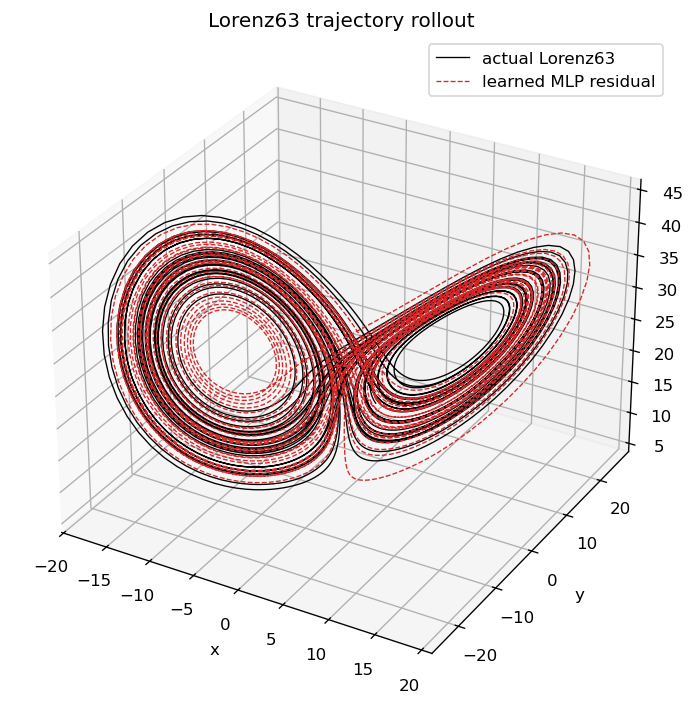

In [106]:
true_np = true_states.detach().cpu().numpy()
pred_np = pred_states.detach().cpu().numpy()
colors = ["tab:blue", "tab:orange", "tab:green"]
state_names = ["x", "y", "z"]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(true_np[:, 0], true_np[:, 1], true_np[:, 2], color="black", lw=0.8, label="actual Lorenz63")
ax.plot(pred_np[:, 0], pred_np[:, 1], pred_np[:, 2], color="tab:red", lw=0.8, linestyle="--", label="learned MLP residual")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Lorenz63 trajectory rollout")
ax.legend()
fig.tight_layout()

if SAVE_FIGURES:
    path = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_predicted_trajectory_3d.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path}")

plt.show()

saved /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/unstructured/lorenz63_residual_mlp/lorenz63_residual_mlp_predicted_timeseries.png


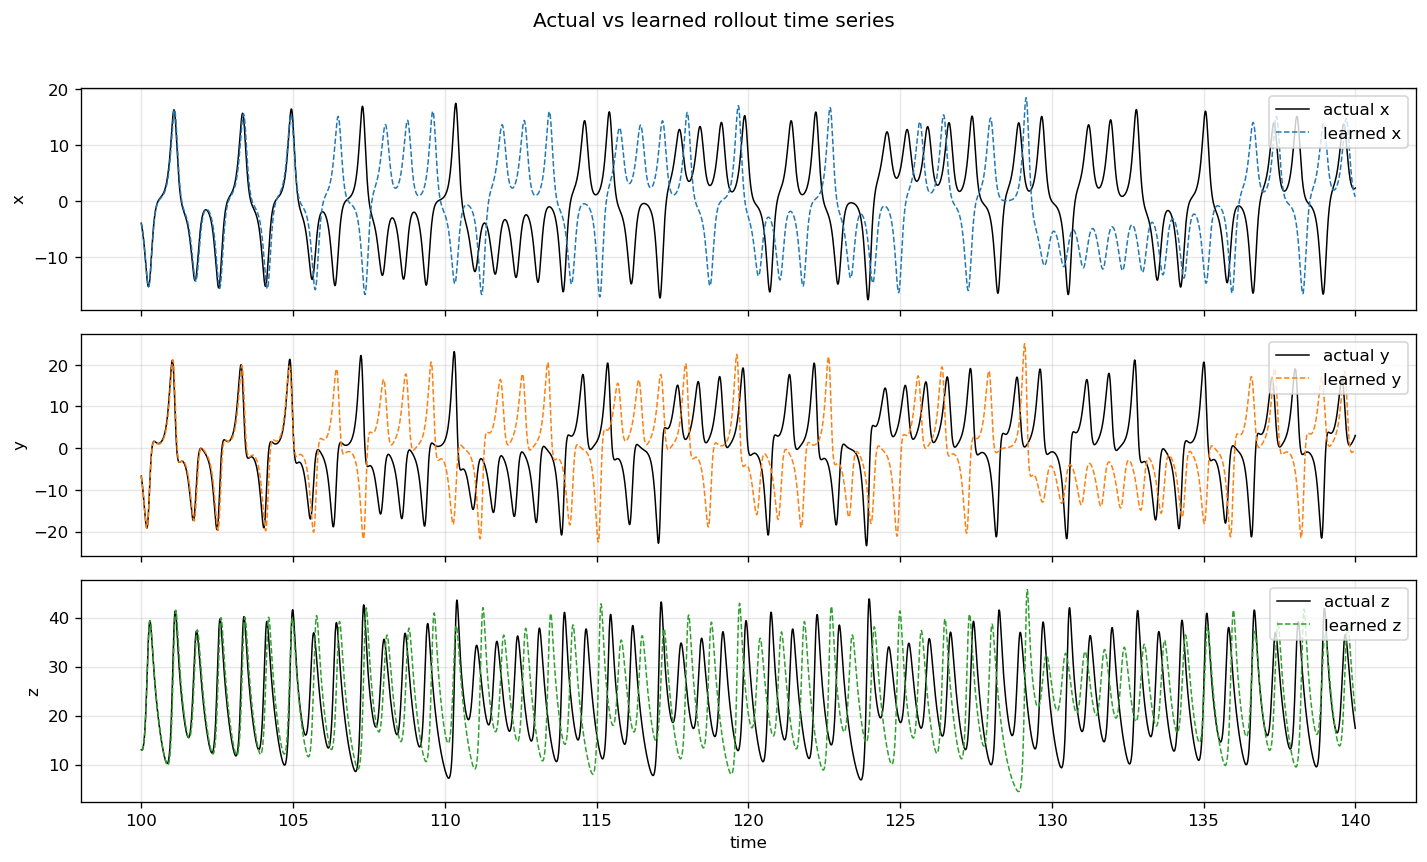

In [107]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

for idx, (ax, name, color) in enumerate(zip(axes, state_names, colors)):
    ax.plot(t_rollout, true_np[:, idx], color="black", lw=0.9, label=f"actual {name}")
    ax.plot(t_rollout, pred_np[:, idx], color=color, lw=0.9, linestyle="--", label=f"learned {name}")
    ax.set_ylabel(name)
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("time")
fig.suptitle("Actual vs learned rollout time series", y=1.02)
fig.tight_layout()

if SAVE_FIGURES:
    path = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_predicted_timeseries.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path}")

plt.show()

## Compare True And Learned Components

The learned model exposes `linear_tendency` and `residual_tendency`, so the linear and residual pieces can be compared directly with the actual Lorenz63 decomposition.

In [108]:
@torch.no_grad()
def compute_component_split(model, x_true):
    A_true = lorenz63_linear_matrix(sigma=sigma, rho=rho, beta=beta).to(x_true.device)
    true_linear = torch.matmul(x_true, A_true.T)
    true_residual = true_lorenz63_residual(x_true)
    true_tendency = true_linear + true_residual

    learned_linear = model.linear_tendency(x_true)
    learned_residual = model.residual_tendency(x_true)
    learned_tendency = learned_linear + learned_residual

    return true_linear, true_residual, true_tendency, learned_linear, learned_residual, learned_tendency


(
    true_linear,
    true_residual,
    true_tendency,
    learned_linear,
    learned_residual,
    learned_tendency,
) = compute_component_split(model, true_states)

linear_rmse = torch.sqrt(torch.mean((learned_linear - true_linear) ** 2, dim=0)).detach().cpu()
residual_rmse = torch.sqrt(torch.mean((learned_residual - true_residual) ** 2, dim=0)).detach().cpu()
tendency_rmse = torch.sqrt(torch.mean((learned_tendency - true_tendency) ** 2, dim=0)).detach().cpu()

print(f"linear component RMSE [dx/dt, dy/dt, dz/dt]: {linear_rmse.tolist()}")
print(f"residual component RMSE [dx/dt, dy/dt, dz/dt]: {residual_rmse.tolist()}")
print(f"total tendency RMSE [dx/dt, dy/dt, dz/dt]: {tendency_rmse.tolist()}")

linear component RMSE [dx/dt, dy/dt, dz/dt]: [0.11572180688381195, 154.66261291503906, 97.9631576538086]
residual component RMSE [dx/dt, dy/dt, dz/dt]: [0.1443478912115097, 154.69810485839844, 97.8108139038086]
total tendency RMSE [dx/dt, dy/dt, dz/dt]: [0.15791359543800354, 0.5733517408370972, 0.5547852516174316]


saved /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/unstructured/lorenz63_residual_mlp/lorenz63_residual_mlp_learned_linear_components.png


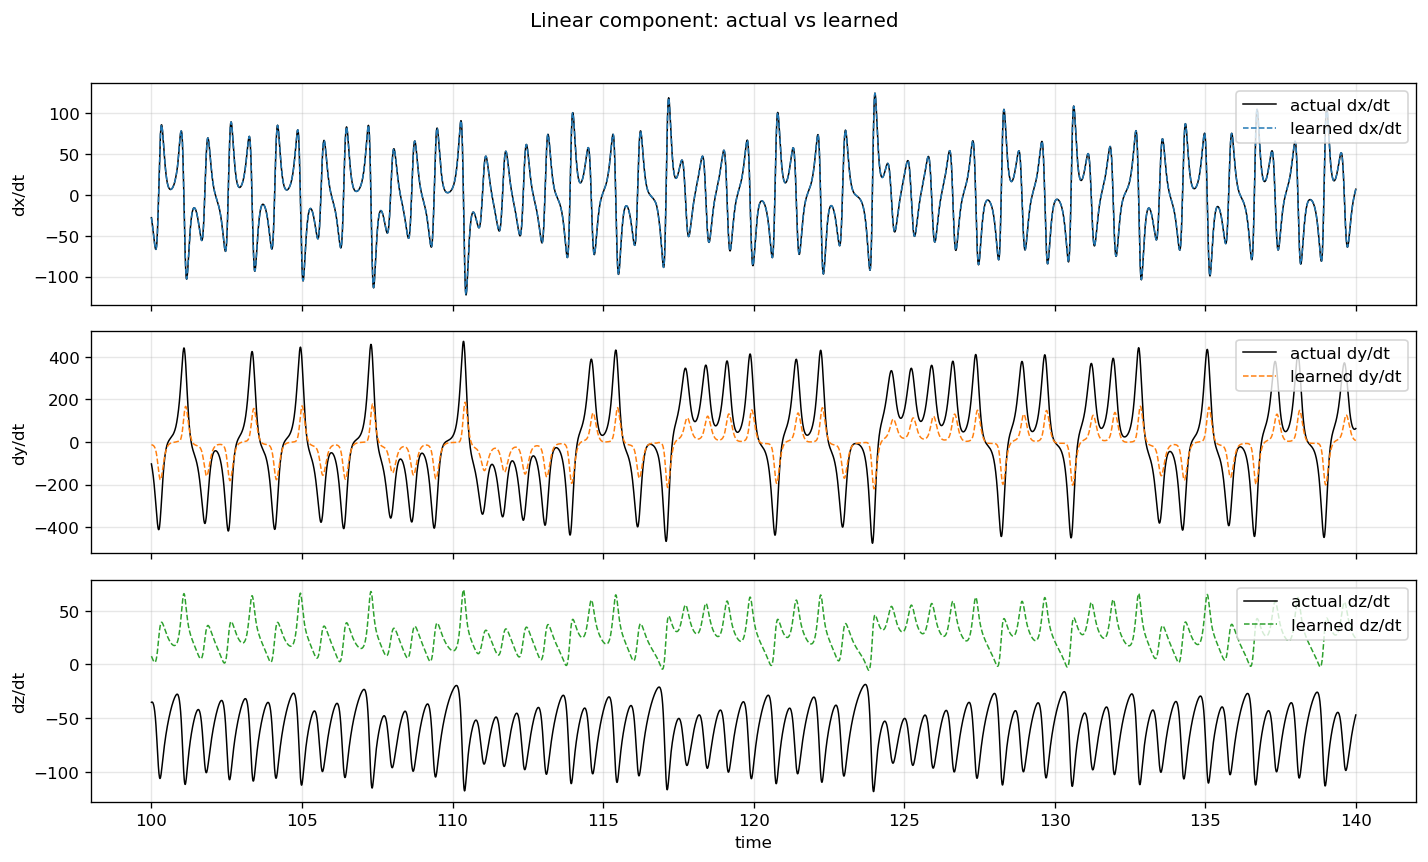

saved /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/unstructured/lorenz63_residual_mlp/lorenz63_residual_mlp_learned_residual_components.png


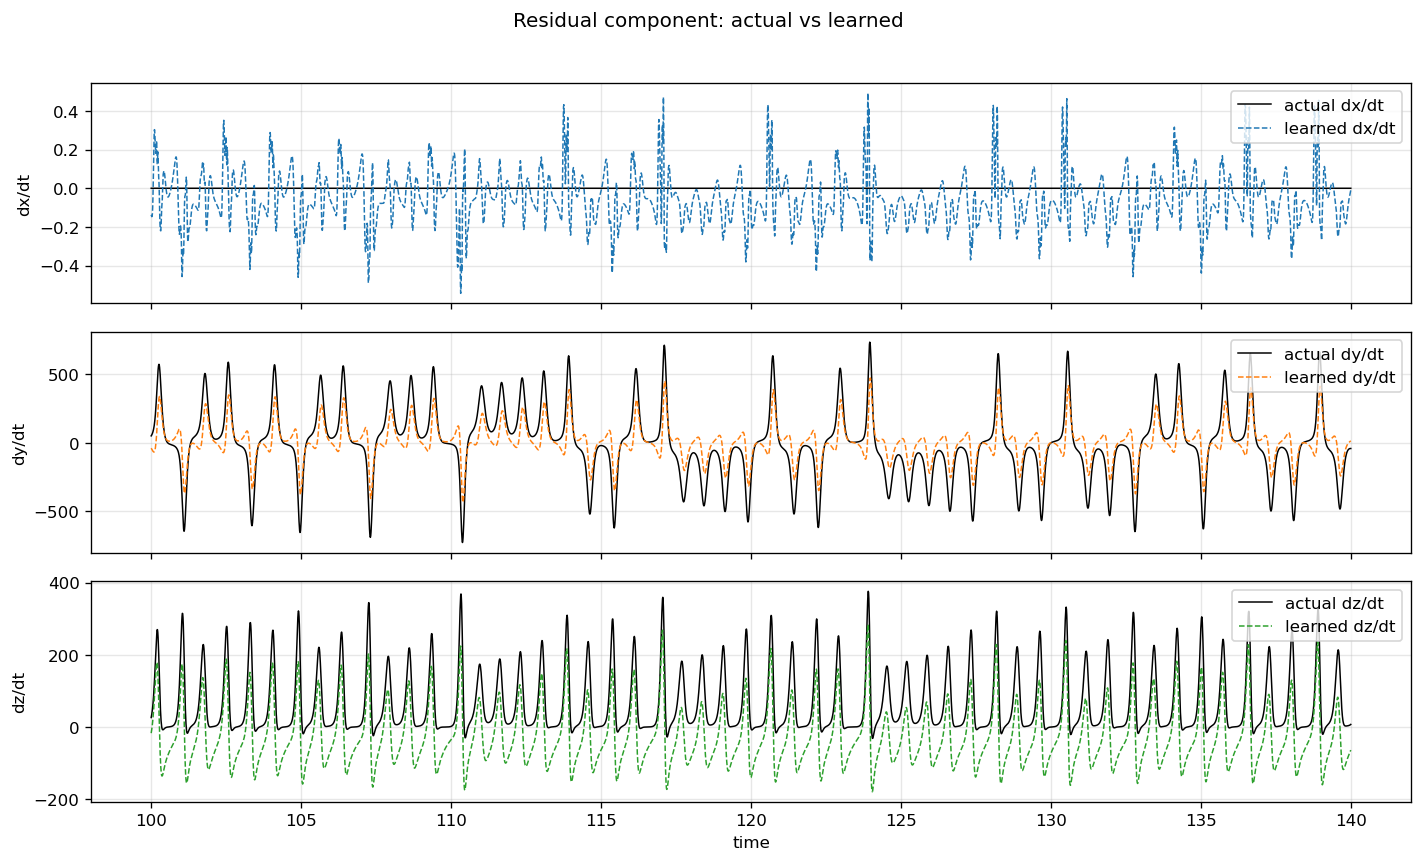

saved /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/unstructured/lorenz63_residual_mlp/lorenz63_residual_mlp_learned_tendency_components.png


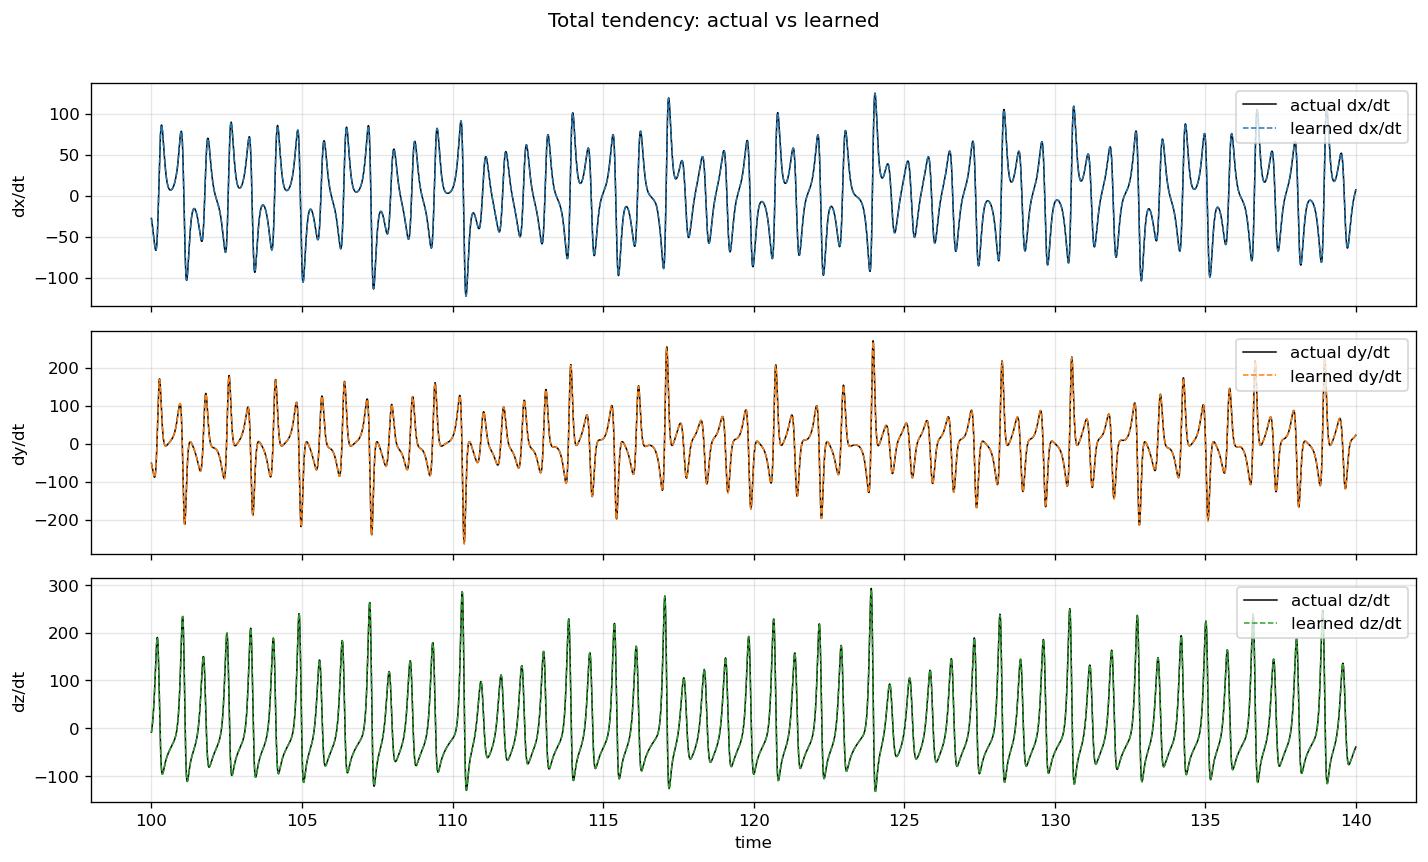

In [109]:
true_linear_np = true_linear.detach().cpu().numpy()
learned_linear_np = learned_linear.detach().cpu().numpy()
true_residual_np = true_residual.detach().cpu().numpy()
learned_residual_np = learned_residual.detach().cpu().numpy()
true_tendency_np = true_tendency.detach().cpu().numpy()
learned_tendency_np = learned_tendency.detach().cpu().numpy()

def _component_timeseries_plot(true_component, learned_component, title, filename_suffix):
    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    for idx, (ax, name, color) in enumerate(zip(axes, ["dx/dt", "dy/dt", "dz/dt"], colors)):
        ax.plot(t_rollout, true_component[:, idx], color="black", lw=0.9, label=f"actual {name}")
        ax.plot(t_rollout, learned_component[:, idx], color=color, lw=0.9, linestyle="--", label=f"learned {name}")
        ax.set_ylabel(name)
        ax.legend(loc="upper right")
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel("time")
    fig.suptitle(title, y=1.02)
    fig.tight_layout()

    if SAVE_FIGURES:
        path = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_{filename_suffix}_components.png"
        fig.savefig(path, dpi=200, bbox_inches="tight")
        print(f"saved {path}")

    plt.show()


_component_timeseries_plot(true_linear_np, learned_linear_np, "Linear component: actual vs learned", "learned_linear")
_component_timeseries_plot(true_residual_np, learned_residual_np, "Residual component: actual vs learned", "learned_residual")
_component_timeseries_plot(true_tendency_np, learned_tendency_np, "Total tendency: actual vs learned", "learned_tendency")

## Component Parity Plots

saved /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/unstructured/lorenz63_residual_mlp/lorenz63_residual_mlp_learned_linear_parity.png


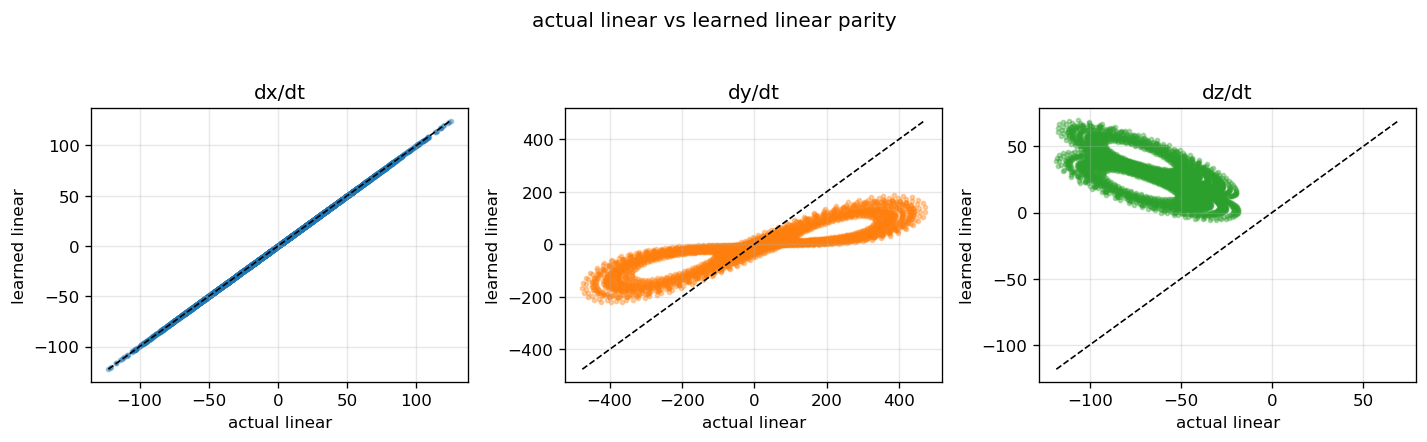

saved /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/unstructured/lorenz63_residual_mlp/lorenz63_residual_mlp_learned_residual_parity.png


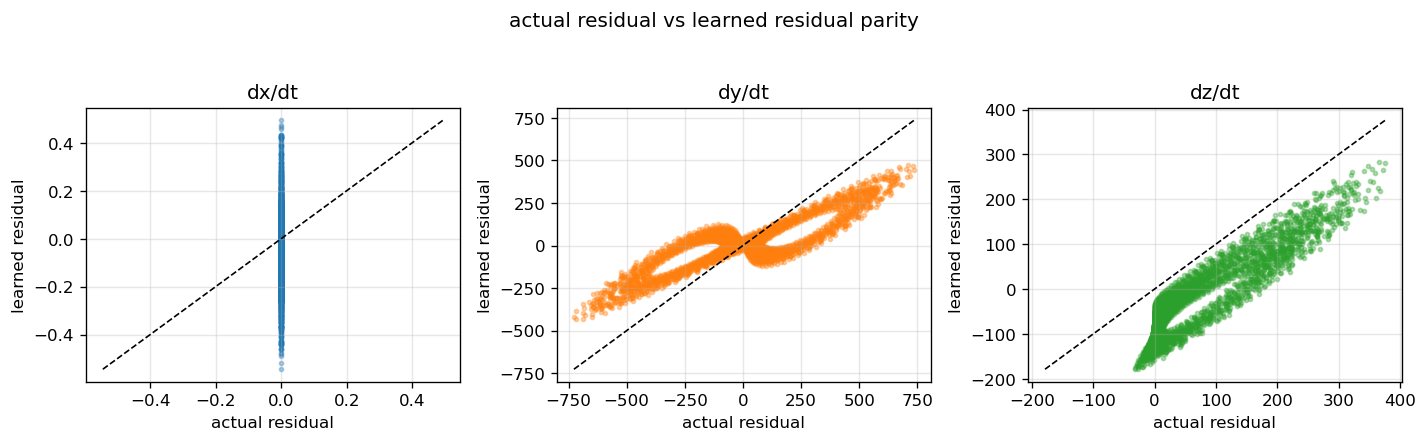

saved /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/unstructured/lorenz63_residual_mlp/lorenz63_residual_mlp_learned_tendency_parity.png


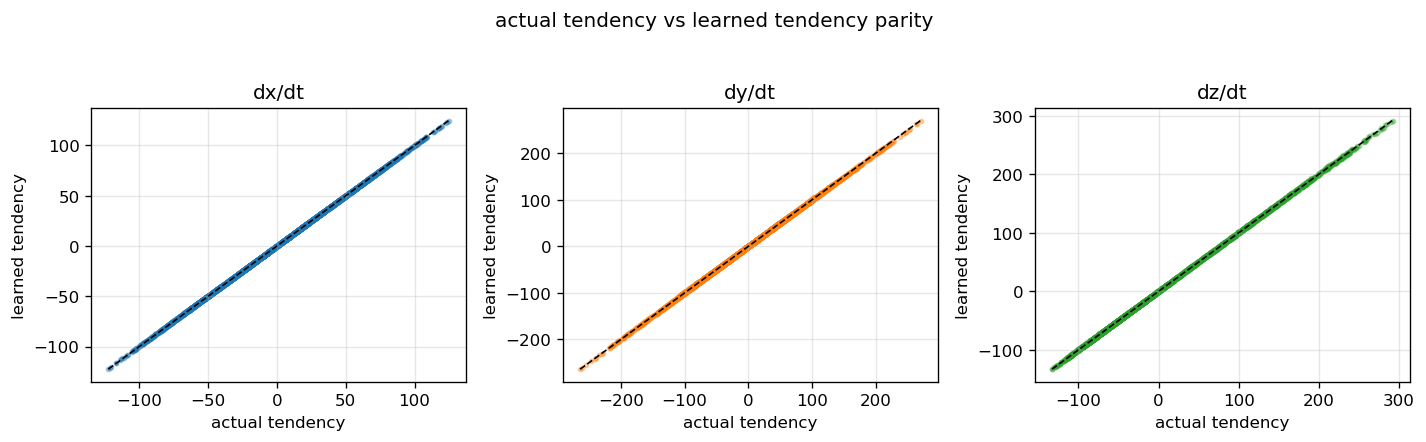

In [110]:
def _component_parity_plot(true_component, learned_component, true_label, learned_label, filename_suffix):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    for idx, (ax, name, color) in enumerate(zip(axes, ["dx/dt", "dy/dt", "dz/dt"], colors)):
        xvals = true_component[:, idx]
        yvals = learned_component[:, idx]
        ax.scatter(xvals, yvals, s=6, alpha=0.35, color=color)
        lo = min(xvals.min(), yvals.min())
        hi = max(xvals.max(), yvals.max())
        ax.plot([lo, hi], [lo, hi], color="black", lw=1.0, linestyle="--")
        ax.set_title(name)
        ax.set_xlabel(true_label)
        ax.set_ylabel(learned_label)
        ax.grid(alpha=0.3)
    fig.suptitle(f"{true_label} vs {learned_label} parity", y=1.04)
    fig.tight_layout()

    if SAVE_FIGURES:
        path = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_{filename_suffix}_parity.png"
        fig.savefig(path, dpi=200, bbox_inches="tight")
        print(f"saved {path}")

    plt.show()


_component_parity_plot(true_linear_np, learned_linear_np, "actual linear", "learned linear", "learned_linear")
_component_parity_plot(true_residual_np, learned_residual_np, "actual residual", "learned residual", "learned_residual")
_component_parity_plot(true_tendency_np, learned_tendency_np, "actual tendency", "learned tendency", "learned_tendency")

## Statistics Comparison

In [111]:
def _sample_stats(values):
    values = np.asarray(values, dtype=np.float64)
    mean = values.mean(axis=0)
    variance = values.var(axis=0)
    std = np.sqrt(variance)
    centered = values - mean
    skewness = np.divide(
        np.mean(centered ** 3, axis=0),
        std ** 3,
        out=np.zeros_like(mean),
        where=std > 0,
    )
    return {"mean": mean, "variance": variance, "skewness": skewness}


def _print_stats_comparison(title, names, actual_values, learned_values):
    actual_stats = _sample_stats(actual_values)
    learned_stats = _sample_stats(learned_values)

    print(title)
    print(f"{'variable':<8} {'statistic':<10} {'actual':>14} {'learned':>14} {'learned-actual':>16}")
    print("-" * 66)
    for idx, name in enumerate(names):
        for stat_name in ["mean", "variance", "skewness"]:
            actual = actual_stats[stat_name][idx]
            learned = learned_stats[stat_name][idx]
            print(f"{name:<8} {stat_name:<10} {actual:>14.6g} {learned:>14.6g} {learned - actual:>16.6g}")
    print()


_print_stats_comparison(
    "State statistics: actual vs learned rollout",
    ["X", "Y", "Z"],
    true_np,
    pred_np,
)
_print_stats_comparison(
    "Tendency statistics: actual vs learned at actual states",
    ["dX", "dY", "dZ"],
    true_tendency_np,
    learned_tendency_np,
)

State statistics: actual vs learned rollout
variable statistic          actual        learned   learned-actual
------------------------------------------------------------------
X        mean             0.159623      -0.652768        -0.812392
X        variance          63.1506        62.9598        -0.190854
X        skewness       -0.0516199       0.139545         0.191165
Y        mean             0.175076      -0.641415        -0.816491
Y        variance           83.249        82.4145        -0.834472
Y        skewness       -0.0638957       0.129402         0.193298
Z        mean              23.3572        23.4095         0.052245
Z        variance          78.2398        78.4422         0.202387
Z        skewness          0.31187       0.258823       -0.0530476

Tendency statistics: actual vs learned at actual states
variable statistic          actual        learned   learned-actual
------------------------------------------------------------------
dX       mean             0.